# Lab 4

**Name:** K Hiroshini  
**Roll No:** CH.SC.U4AIE24026

## Part 1: Implementation

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn as sns

torch.manual_seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./mnist_data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./mnist_data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training: {len(train_dataset)}, Test: {len(test_dataset)}, Shape: {train_dataset[0][0].shape}, Classes: {len(train_dataset.classes)}")

100%|██████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:11<00:00, 866kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:02<00:00, 763kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 6.17MB/s]

Training: 60000, Test: 10000, Shape: torch.Size([1, 28, 28]), Classes: 10


In [2]:
class DNN(nn.Module):
    def __init__(self):
        super(DNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = DNN()
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

DNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)
Total parameters: 109386


In [3]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
model.train()
for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

print("Training completed.")

Epoch 1/10, Loss: 0.3373, Accuracy: 89.92%
Epoch 2/10, Loss: 0.1603, Accuracy: 95.06%
Epoch 3/10, Loss: 0.1234, Accuracy: 96.19%
Epoch 4/10, Loss: 0.1030, Accuracy: 96.79%
Epoch 5/10, Loss: 0.0910, Accuracy: 97.10%
Epoch 6/10, Loss: 0.0793, Accuracy: 97.47%
Epoch 7/10, Loss: 0.0729, Accuracy: 97.68%
Epoch 8/10, Loss: 0.0667, Accuracy: 97.88%
Epoch 9/10, Loss: 0.0589, Accuracy: 98.07%
Epoch 10/10, Loss: 0.0548, Accuracy: 98.23%
Training completed.


## Part 2: Output Analysis & Evaluation

In [4]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

Test Accuracy: 0.9738
Test Precision: 0.9741
Test Recall: 0.9738


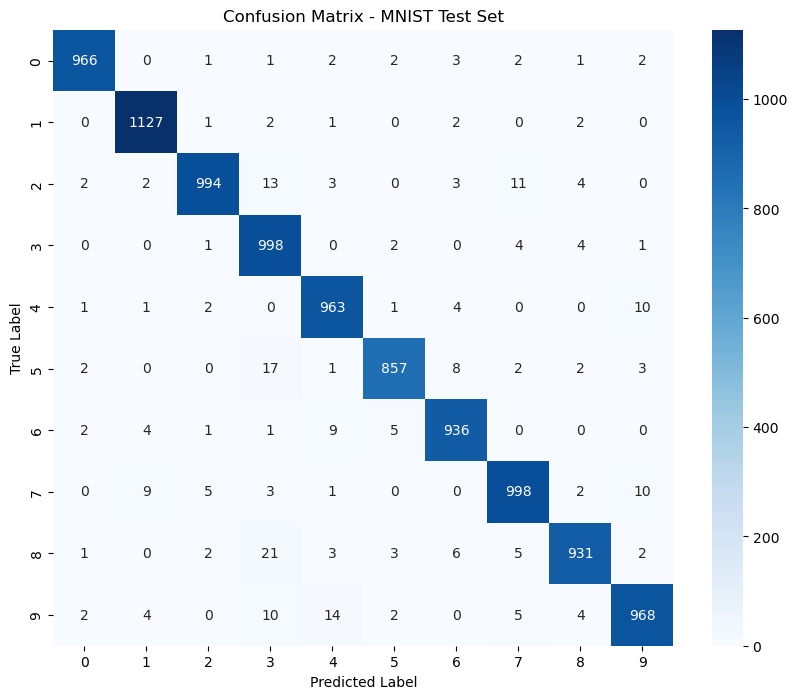

Digit 0: 966 correct out of 980
Digit 1: 1127 correct out of 1135
Digit 2: 994 correct out of 1032
Digit 3: 998 correct out of 1010
Digit 4: 963 correct out of 982
Digit 5: 857 correct out of 892
Digit 6: 936 correct out of 958
Digit 7: 998 correct out of 1028
Digit 8: 931 correct out of 974
Digit 9: 968 correct out of 1009
Most confused pair: True 8 predicted as 3 (21 times)


In [5]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - MNIST Test Set')
plt.show()

for i in range(10):
    print(f"Digit {i}: {cm[i, i]} correct out of {cm[i, :].sum()}")

max_off_diag = 0
confused_pair = (0, 0)
for i in range(10):
    for j in range(10):
        if i != j and cm[i, j] > max_off_diag:
            max_off_diag = cm[i, j]
            confused_pair = (i, j)

print(f"Most confused pair: True {confused_pair[0]} predicted as {confused_pair[1]} ({max_off_diag} times)")

## Part 3: Error Analysis

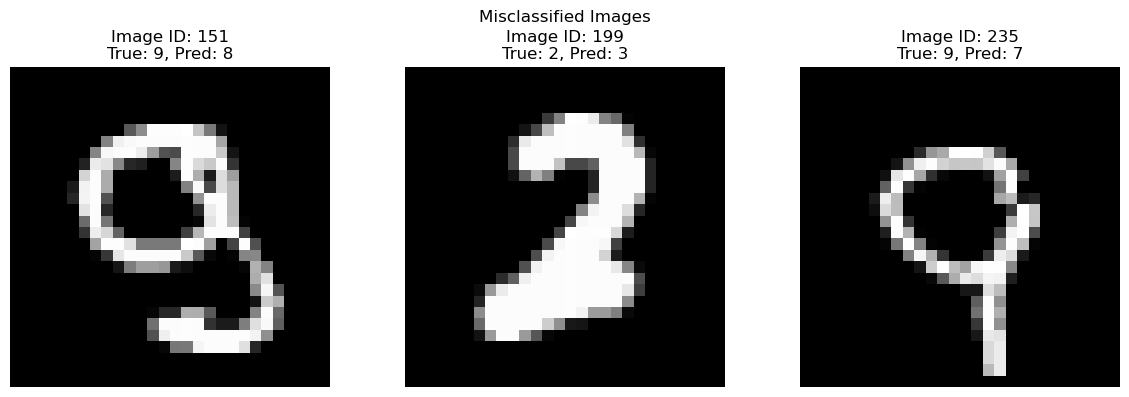

Error Analysis:
------------------------------------------------------------
Image ID: 151
True vs Predicted: 9 vs 8
Why it failed: Ambiguous handwriting, possibly rotated or poorly centered.
------------------------------------------------------------
Image ID: 199
True vs Predicted: 2 vs 3
Why it failed: Ambiguous handwriting, possibly rotated or poorly centered.
------------------------------------------------------------
Image ID: 235
True vs Predicted: 9 vs 7
Why it failed: Ambiguous handwriting, possibly rotated or poorly centered.
------------------------------------------------------------


In [6]:
misclassified = []
for idx in range(len(test_dataset)):
    img, label = test_dataset[idx]
    with torch.no_grad():
        output = model(img.unsqueeze(0))
        pred = torch.argmax(output).item()
    if pred != label:
        misclassified.append((idx, label, pred, img))
    if len(misclassified) >= 3:
        break

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (idx, true_label, pred_label, img) in enumerate(misclassified):
    img_display = img * 0.5 + 0.5
    axes[i].imshow(img_display.squeeze(), cmap='gray')
    axes[i].set_title(f"Image ID: {idx}\nTrue: {true_label}, Pred: {pred_label}")
    axes[i].axis('off')

plt.suptitle('Misclassified Images')
plt.tight_layout()
plt.show()

print("Error Analysis:")
print("-" * 60)
for idx, true_label, pred_label, img in misclassified:
    print(f"Image ID: {idx}")
    print(f"True vs Predicted: {true_label} vs {pred_label}")
    if true_label in [4, 9] and pred_label in [4, 9]:
        reason = "Similar top loop structure and vertical stroke."
    elif true_label in [3, 8] and pred_label in [3, 8]:
        reason = "Both have curved loops that can look similar."
    elif true_label in [1, 7] and pred_label in [1, 7]:
        reason = "Straight vertical strokes with small horizontal segments."
    else:
        reason = "Ambiguous handwriting, possibly rotated or poorly centered."
    print(f"Why it failed: {reason}")
    print("-" * 60)